First 5 Rows
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0 

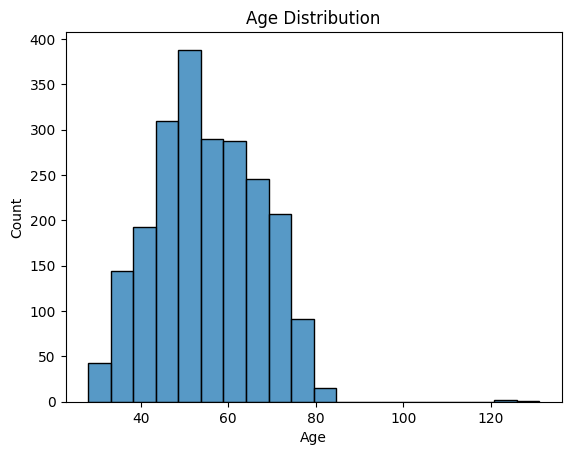

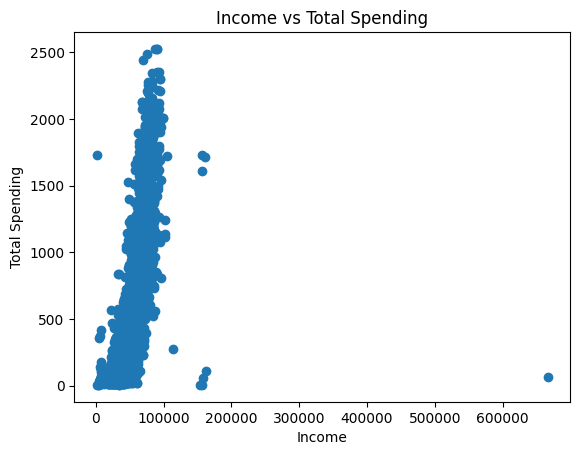

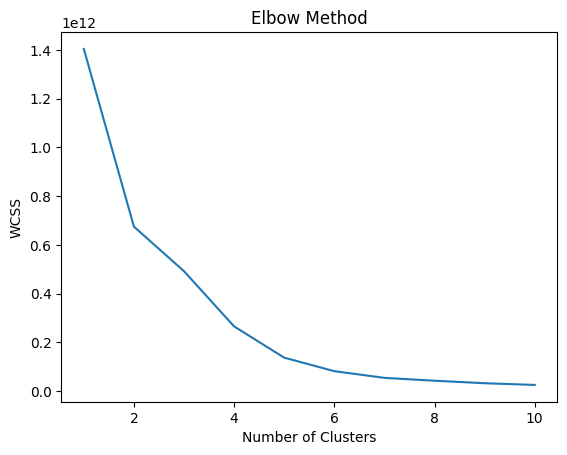

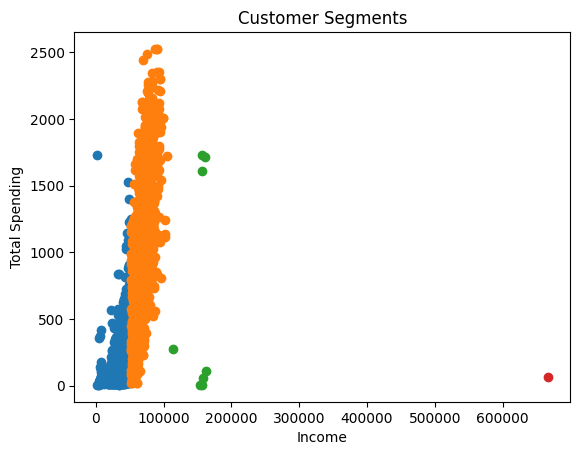


Cluster Summary
                Income  Total_Spending
Cluster                               
0         34356.941229      159.876224
1         69474.625461     1070.261993
2        152488.000000      689.000000
3        666666.000000       62.000000


In [ ]:
# =====================================================
# Customer Segmentation Analysis - Marketing Analytics
# =====================================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset from URL
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv"

data = pd.read_csv(url, sep=";")

# Step 3: Display Dataset
print("First 5 Rows")
print(data.head())

print("\nDataset Shape")
print(data.shape)

print("\nColumns")
print(data.columns)

# Step 4: Dataset Information
print("\nDataset Info")
print(data.info())

# Step 5: Check Missing Values
print("\nMissing Values")
print(data.isnull().sum())

# Step 6: Handle Missing Values
data = data.dropna()

# =========================================
# Feature Engineering
# =========================================

# Create Age Column
data["Age"] = 2024 - data["Year_Birth"]

# Create Total Spending Column
data["Total_Spending"] = (
    data["MntWines"]
    + data["MntFruits"]
    + data["MntMeatProducts"]
    + data["MntFishProducts"]
    + data["MntSweetProducts"]
    + data["MntGoldProds"]
)

# Display new columns
print("\nNew Columns Added")
print(data[["Age","Total_Spending"]].head())

# =========================================
# Data Visualization
# =========================================

# Age Distribution
plt.figure()
sns.histplot(data["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

# Income vs Spending
plt.figure()
plt.scatter(data["Income"], data["Total_Spending"])
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Income vs Total Spending")
plt.show()

# =========================================
# Customer Segmentation
# =========================================

from sklearn.cluster import KMeans

# Select Features
X = data[["Income","Total_Spending"]]

# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# =========================================
# Apply K-Means Clustering
# =========================================

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X)

data["Cluster"] = clusters

# =========================================
# Visualize Customer Segments
# =========================================

plt.figure()

plt.scatter(
    data[data["Cluster"]==0]["Income"],
    data[data["Cluster"]==0]["Total_Spending"]
)

plt.scatter(
    data[data["Cluster"]==1]["Income"],
    data[data["Cluster"]==1]["Total_Spending"]
)

plt.scatter(
    data[data["Cluster"]==2]["Income"],
    data[data["Cluster"]==2]["Total_Spending"]
)

plt.scatter(
    data[data["Cluster"]==3]["Income"],
    data[data["Cluster"]==3]["Total_Spending"]
)

plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Customer Segments")
plt.show()

# =========================================
# Cluster Analysis
# =========================================

print("\nCluster Summary")
print(data.groupby("Cluster")[["Income","Total_Spending"]].mean())